
# Practical 24: U‑Net Family (**U‑Net, Residual U‑Net, Attention U‑Net, U‑Net++**)

**Goal:** Build, train, and compare several U‑Net variants on the **PH2 skin‑lesion dataset** for binary segmentation (lesion vs. background).  



### What you'll learn
- How U‑Net works and where its strengths/limitations are.
- The architectural ideas behind **Residual U‑Net**, **Attention U‑Net**, and **U‑Net++**.
- How to **prepare PH2** (skin lesion) data (convert masks 0/255 → 0/1, splits, augmentations).
- How to implement a **clean, modular PyTorch training loop** and compute **Dice/IoU**.
- How to **compare models** fairly (same data splits, image size, training budget).
- How to visualize qualitative results and interpret failure cases.


## Deeper Explanations (Why these variants?)

- **Residual U‑Net**: Residual blocks learn *residual functions* which (i) help gradient flow in deeper networks, (ii) reduce optimization difficulty, and (iii) often improve convergence speed and robustness.
- **Attention U‑Net**: Attention gates *weight spatial features* from encoder skips based on decoder context. For medical images with large backgrounds and small lesions, this helps **suppress irrelevant regions** and focus on suspicious patterns.
- **U‑Net++**: Dense skip pathways let the decoder **refine features across multiple semantic levels** before fusion, reducing the semantic gap between encoder/decoder. Optional **deep supervision** further stabilizes training.


## How this connects with earlier Practicals
- **Practical 22** introduced binary segmentation with a compact U‑Net.
- **Practical 23** (if you covered multiclass segmentation) showed mask handling for more than two classes.
- Here, we **keep the same learning arc** but compare **four related architectures** under identical settings to build intuition about design trade‑offs.



## Dataset: **PH2** (Skin Lesion - Binary Segmentation)

- **Source:** Kaggle → <https://www.kaggle.com/datasets/spacesurfer/ph2-dataset>  
- **Task:** Segment the lesion region (foreground) from skin images (background).  
- **Masks:** Stored as **0** (background) and **255** (lesion). We'll normalize to **0/1**.

### Download options
**A. Kaggle API (recommended):**
1. Create a Kaggle account and obtain your API token (`kaggle.json`) from *Account → Create New API Token*.
2. Put `kaggle.json` at:
   - Windows: `C:\Users\<you>\.kaggle\kaggle.json`
   - Linux/macOS: `~/.kaggle/kaggle.json`
3. In a terminal or a notebook cell run:
   ```bash
   kaggle datasets download -d spacesurfer/ph2-dataset -p ./data --unzip
   ```

**B. Manual download:** Download from the Kaggle page, unzip into `./data/PH2` so that you have something like:
```
data/PH2/
  images/  (all color images)
  masks/   (binary masks: 0/255)
```

> If your folder names differ, just update the `DATA_DIR`, `IM_DIR`, `MASK_DIR` below.


In [ ]:

# ==== Setup & Imports =========================================================
# If some packages are missing, uncomment the pip lines.

# !pip install -q opencv-python albumentations scikit-learn matplotlib numpy tqdm
# !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# For CUDA, visit https://pytorch.org/get-started/locally/ and install the right wheels.

import os, glob, random, math, time
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:

# ==== Configuration ============================================================
class CFG:
    DATA_DIR = "data/PH2"         # <<-- change if needed
    IM_DIR   = "images"
    MASK_DIR = "masks"
    IMG_SIZE = 256                  # common resolution for all models
    BATCH    = 16
    EPOCHS   = 10                   # set small for quick runs; increase for better results
    LR       = 1e-3
    NUM_WORKERS = 0
    VAL_SPLIT = 0.2
    TEST_SPLIT = 0.1                # from the remainder after val-split
    AUG_STRONG = False              # turn ON for stronger augmentations

cfg = CFG()


In [ ]:

# ==== Data Utilities ===========================================================
IMG_EXTS  = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

def _is_img(path):
    return Path(path).suffix.lower() in IMG_EXTS

def binarize_mask(mask):
    """Convert 0/255 mask -> 0/1 float32. Accepts HxW uint8 (or HxW x {1,3})."""
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    mask = (mask > 127).astype(np.float32)  # 0 or 1
    return mask

def list_image_mask_pairs(root, im_dir="images", mask_dir="masks"):
    im_dir = Path(root)/im_dir
    mk_dir = Path(root)/mask_dir
    im_paths = [p for p in im_dir.rglob("*") if _is_img(p)]
    mk_paths = [p for p in mk_dir.rglob("*") if _is_img(p)]

    # Extract numeric index from filenames
    def get_index(name):
        # expects format: X_img_N.bmp or Y_img_N.bmp
        parts = name.split('_')
        try:
            return int(parts[-1].split('.')[0])
        except Exception:
            return None

    im_map = {get_index(p.name): p for p in im_paths}
    mk_map = {get_index(p.name): p for p in mk_paths}

    pairs = []
    for idx, imp in im_map.items():
        if idx is not None and idx in mk_map:
            pairs.append((str(imp), str(mk_map[idx])))
    return pairs

class PH2Dataset(Dataset):
    def __init__(self, pairs, img_size=256, aug=False):
        self.pairs = pairs
        self.img_size = img_size
        self.aug = aug

    def __len__(self): return len(self.pairs)

    def _load_image(self, path):
        im = cv2.imread(path, cv2.IMREAD_COLOR)
        if im is None:
            raise FileNotFoundError(f"Could not read image: {path}")
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        return im

    def _load_mask(self, path):
        mk = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mk is None:
            raise FileNotFoundError(f"Could not read mask: {path}")
        mk = binarize_mask(mk)  # 0/1
        return mk

    def _resize(self, im, mk):
        im = cv2.resize(im, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mk = cv2.resize(mk, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        return im, mk

    def _augment(self, im, mk):
        # Light augmentations that preserve lesion structure.
        # You can switch AUG_STRONG to True for more aggressive transforms.
        if self.aug:
            if random.random() < 0.5:
                im = np.ascontiguousarray(np.fliplr(im))
                mk = np.ascontiguousarray(np.fliplr(mk))
            if random.random() < 0.5:
                im = np.ascontiguousarray(np.flipud(im))
                mk = np.ascontiguousarray(np.flipud(mk))
            # small rotations
            if random.random() < 0.3:
                angle = random.uniform(-15, 15)
                h, w = mk.shape
                M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                im = cv2.warpAffine(im, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
                mk = cv2.warpAffine(mk, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
        return im, mk

    def __getitem__(self, idx):
        im_path, mk_path = self.pairs[idx]
        im = self._load_image(im_path)
        mk = self._load_mask(mk_path)
        im, mk = self._resize(im, mk)
        im, mk = self._augment(im, mk)
        im = (im/255.0).astype(np.float32)
        im = im.transpose(2,0,1)  # CHW
        mk = mk[None, ...]        # 1xHxW
        return torch.from_numpy(im), torch.from_numpy(mk)


In [ ]:

# ==== Build Splits & DataLoaders ==============================================
all_pairs = list_image_mask_pairs(cfg.DATA_DIR, cfg.IM_DIR, cfg.MASK_DIR)
print(f"Found {len(all_pairs)} image/mask pairs. (Expect ~200 for PH2)")

if len(all_pairs) < 10:
    warning_text = (
        "[Warning] Very few pairs found.\n"
        "Make sure your dataset is at cfg.DATA_DIR with subfolders:\n"
        "  images/  and  masks/\n"
        "and that masks share the same filename stems (with possible suffixes like _lesion/_mask)."
    )
    print(warning_text)

train_pairs, valtest_pairs = train_test_split(all_pairs, test_size=cfg.VAL_SPLIT, random_state=SEED)
val_pairs, test_pairs = train_test_split(valtest_pairs, test_size=cfg.TEST_SPLIT, random_state=SEED)

train_ds = PH2Dataset(train_pairs, img_size=cfg.IMG_SIZE, aug=True)
val_ds   = PH2Dataset(val_pairs,   img_size=cfg.IMG_SIZE, aug=False)
test_ds  = PH2Dataset(test_pairs,  img_size=cfg.IMG_SIZE, aug=False)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH, shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)


Found 200 image/mask pairs. (Expect ~200 for PH2)


(160, 36, 4)

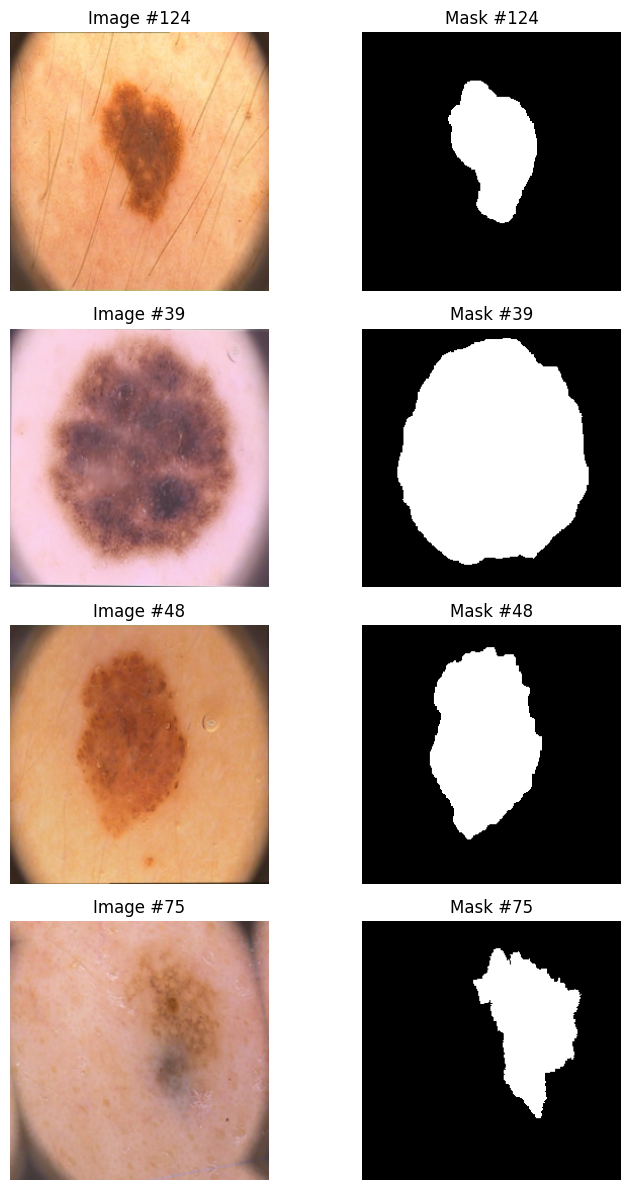

In [ ]:

# ==== Peek at a few samples ====================================================
def show_batch(ds, n=4):
    if len(ds) == 0:
        print("Dataset is empty; nothing to show.")
        return
    idxs = random.sample(range(len(ds)), k=min(n, len(ds)))
    num_rows = len(idxs)
    fig, axes = plt.subplots(num_rows, 2, figsize=(8, 3*num_rows))
    for i, idx in enumerate(idxs):
        im, mk = ds[idx]
        im_np = (im.numpy().transpose(1,2,0)*255).astype(np.uint8)
        mk_np = (mk.numpy().squeeze()*255).astype(np.uint8)
        axes[i, 0].imshow(im_np)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f"Image #{idx}")
        axes[i, 1].imshow(mk_np, cmap='gray')
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f"Mask #{idx}")
    plt.tight_layout()
    plt.show()

show_batch(train_ds, n=4)



## U‑Net Family: Key Ideas

- **U‑Net**: Encoder–decoder with skip connections to recover fine details.
- **Residual U‑Net**: Replace plain conv blocks with **residual blocks** (helps gradient flow, eases optimization).
- **Attention U‑Net**: Add **attention gates** on skip connections to **suppress irrelevant regions**.
- **U‑Net++**: **Nested, dense skip connections** and optional **deep supervision** to refine multi‑scale fusion.

Below, we implement compact, readable versions of all four. We keep the **same depth and base channels** for fair comparison.


In [ ]:

# ==== Building Blocks ==========================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.need_proj = (in_ch != out_ch)
        if self.need_proj:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.need_proj:
            identity = self.proj(identity)
        out = self.relu(out + identity)
        return out

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
    def forward(self, x): return self.up(x)

class AttentionGate(nn.Module):
    """Simple additive attention gate used in Attention U-Net.
    g: decoder signal; x: skip connection"""
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.Wg = nn.Sequential(nn.Conv2d(g_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.Wx = nn.Sequential(nn.Conv2d(x_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=True), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        # upsample g if needed
        if g.shape[-1] != x.shape[-1] or g.shape[-2] != x.shape[-2]:
            g = F.interpolate(g, size=x.shape[-2:], mode='bilinear', align_corners=False)
        out = self.relu(self.Wg(g) + self.Wx(x))
        alpha = self.psi(out)
        return x * alpha


In [ ]:

# ============================= U-Net ===========================================
class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32, block=ConvBlock):
        super().__init__()
        self.enc1 = block(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = block(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = block(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = block(base*4, base*8)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = block(base*8, base*16)

        self.up4 = UpBlock(base*16, base*8)
        self.dec4 = block(base*16, base*8)
        self.up3 = UpBlock(base*8, base*4)
        self.dec3 = block(base*8, base*4)
        self.up2 = UpBlock(base*4, base*2)
        self.dec2 = block(base*4, base*2)
        self.up1 = UpBlock(base*2, base)
        self.dec1 = block(base*2, base)

        self.head = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.head(d1)
        return out


In [ ]:

# ============================== Residual U-Net =================================
class ResUNet(UNet):
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__(in_ch=in_ch, out_ch=out_ch, base=base, block=ResidualBlock)


In [ ]:

# ================================ Attention U-Net ==============================
class AttUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32, block=ConvBlock):
        super().__init__()
        self.enc1 = block(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = block(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = block(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = block(base*4, base*8)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = block(base*8, base*16)

        self.up4 = UpBlock(base*16, base*8)
        self.att4 = AttentionGate(g_ch=base*8, x_ch=base*8, inter_ch=base*4)
        self.dec4 = block(base*16, base*8)

        self.up3 = UpBlock(base*8, base*4)
        self.att3 = AttentionGate(g_ch=base*4, x_ch=base*4, inter_ch=base*2)
        self.dec3 = block(base*8, base*4)

        self.up2 = UpBlock(base*4, base*2)
        self.att2 = AttentionGate(g_ch=base*2, x_ch=base*2, inter_ch=base)
        self.dec2 = block(base*4, base*2)

        self.up1 = UpBlock(base*2, base)
        self.att1 = AttentionGate(g_ch=base, x_ch=base, inter_ch=base//2 if base>=2 else 1)
        self.dec1 = block(base*2, base)

        self.head = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        d4 = self.up4(b)
        e4_att = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4_att], dim=1))

        d3 = self.up3(d4)
        e3_att = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3_att], dim=1))

        d2 = self.up2(d3)
        e2_att = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2_att], dim=1))

        d1 = self.up1(d2)
        e1_att = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1_att], dim=1))

        return self.head(d1)


In [ ]:

# ============================= U-Net++ (Nested U-Net) ==========================
class UNetPP(nn.Module):
    """A compact Nested U-Net (U-Net++) without deep supervision by default."""
    def __init__(self, in_ch=3, out_ch=1, base=32, block=ConvBlock, deep_supervision=False):
        super().__init__()
        self.deep_supervision = deep_supervision

        def conv(in_c, out_c): return block(in_c, out_c)

        self.conv00 = conv(in_ch, base)
        self.pool0 = nn.MaxPool2d(2)
        self.conv10 = conv(base, base*2)
        self.pool1 = nn.MaxPool2d(2)
        self.conv20 = conv(base*2, base*4)
        self.pool2 = nn.MaxPool2d(2)
        self.conv30 = conv(base*4, base*8)
        self.pool3 = nn.MaxPool2d(2)
        self.conv40 = conv(base*8, base*16)

        self.up01 = UpBlock(base*2, base)
        self.conv01 = conv(base + base, base)

        self.up11 = UpBlock(base*4, base*2)
        self.conv11 = conv(base*2 + base*2, base*2)

        self.up21 = UpBlock(base*8, base*4)
        self.conv21 = conv(base*4 + base*4, base*4)

        self.up31 = UpBlock(base*16, base*8)
        self.conv31 = conv(base*8 + base*8, base*8)

        self.up02 = UpBlock(base*2, base)
        self.conv02 = conv(base*2 + base, base)

        self.up12 = UpBlock(base*4, base*2)
        self.conv12 = conv(base*4 + base*2, base*2)

        self.up22 = UpBlock(base*8, base*4)
        self.conv22 = conv(base*8 + base*4, base*4)

        self.up03 = UpBlock(base*2, base)
        self.conv03 = conv(base*3 + base, base)

        if deep_supervision:
            self.head1 = nn.Conv2d(base, out_ch, 1)
            self.head2 = nn.Conv2d(base, out_ch, 1)
            self.head3 = nn.Conv2d(base, out_ch, 1)
        else:
            self.head = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        x00 = self.conv00(x)              # stage 0, level 0
        x10 = self.conv10(self.pool0(x00))
        x20 = self.conv20(self.pool1(x10))
        x30 = self.conv30(self.pool2(x20))
        x40 = self.conv40(self.pool3(x30))

        x01 = self.conv01(torch.cat([x00, self.up01(x10)], dim=1))
        x11 = self.conv11(torch.cat([x10, self.up11(x20)], dim=1))
        x21 = self.conv21(torch.cat([x20, self.up21(x30)], dim=1))
        x31 = self.conv31(torch.cat([x30, self.up31(x40)], dim=1))

        x02 = self.conv02(torch.cat([x00, x01, self.up02(x11)], dim=1))
        x12 = self.conv12(torch.cat([x10, x11, self.up12(x21)], dim=1))
        x22 = self.conv22(torch.cat([x20, x21, self.up22(x31)], dim=1))

        x03 = self.conv03(torch.cat([x00, x01, x02, self.up03(x12)], dim=1))

        if hasattr(self, 'head1'):
            # Example: average deep supervision
            out1 = self.head1(x01)
            out2 = self.head2(x02)
            out3 = self.head3(x03)
            out1 = F.interpolate(out1, size=x.shape[-2:], mode='bilinear', align_corners=False)
            out2 = F.interpolate(out2, size=x.shape[-2:], mode='bilinear', align_corners=False)
            out3 = F.interpolate(out3, size=x.shape[-2:], mode='bilinear', align_corners=False)
            return (out1 + out2 + out3) / 3.0
        else:
            out = self.head(x03)
            return out


In [ ]:

# =============================== Losses & Metrics ==============================
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        num = 2 * (probs*targets).sum(dim=(2,3)) + self.eps
        den = (probs+targets).sum(dim=(2,3)) + self.eps
        dice = num / den
        return 1 - dice.mean()

def dice_coef(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs*targets).sum(dim=(2,3)) + eps
    den = (probs+targets).sum(dim=(2,3)) + eps
    return (num/den).mean().item()

def iou_score(logits, targets, thresh=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    inter = (preds*targets).sum(dim=(2,3))
    union = (preds + targets - preds*targets).sum(dim=(2,3)) + eps
    return (inter/union).mean().item()


In [ ]:

# =============================== Training Loop =================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for imgs, masks in tqdm(loader, leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks) + F.binary_cross_entropy_with_logits(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*imgs.size(0)
    return total_loss/len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    count = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks) + F.binary_cross_entropy_with_logits(logits, masks)
        total_loss += loss.item()*imgs.size(0)
        total_dice += dice_coef(logits, masks)*imgs.size(0)
        total_iou  += iou_score(logits, masks)*imgs.size(0)
        count += imgs.size(0)
    return total_loss/count, total_dice/count, total_iou/count


In [ ]:

# ================================= Compare Models ==============================
def make_model(name, in_ch=3, out_ch=1, base=32):
    name = name.lower()
    if name == "unet":
        return UNet(in_ch, out_ch, base)
    if name == "resunet":
        return ResUNet(in_ch, out_ch, base)
    if name == "attunet":
        return AttUNet(in_ch, out_ch, base)
    if name in ["unet++","unetpp","nested_unet"]:
        return UNetPP(in_ch, out_ch, base, deep_supervision=False)
    raise ValueError(f"Unknown model: {name}")

models_to_try = ["unet", "resunet", "attunet", "unet++"]

results = []
criterion = DiceLoss()

if len(train_ds) > 0:
    for mname in models_to_try:
        print(f"\n===== Training {mname.upper()} =====")
        model = make_model(mname, in_ch=3, out_ch=1, base=32).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR)
        best_val = 1e9
        best_state = None

        history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
        for epoch in range(cfg.EPOCHS):
            tl = train_one_epoch(model, train_loader, optimizer, criterion)
            vl, vd, vi = evaluate(model, val_loader, criterion)
            history["train_loss"].append(tl)
            history["val_loss"].append(vl)
            history["val_dice"].append(vd)
            history["val_iou"].append(vi)
            print(f"Epoch {epoch+1:02d}/{cfg.EPOCHS} | train_loss {tl:.4f} | val_loss {vl:.4f} | dice {vd:.4f} | iou {vi:.4f}")
            if vl < best_val:
                best_val = vl
                best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        # Restore best
        if best_state is not None:
            model.load_state_dict(best_state)

        # Final test
        te_l, te_d, te_i = evaluate(model, test_loader, criterion)
        params = sum(p.numel() for p in model.parameters())
        results.append({
            "model": mname,
            "params_M": round(params/1e6, 3),
            "val_dice_best": max(history["val_dice"]) if history["val_dice"] else None,
            "val_iou_best":  max(history["val_iou"])  if history["val_iou"]  else None,
            "test_loss": te_l, "test_dice": te_d, "test_iou": te_i,
            "history": history,
            "state_dict": best_state
        })
else:
    print("Skip training: dataset not found. Once data is ready, re-run this cell.")



===== Training UNET =====


Epoch 01/10 | train_loss 0.9107 | val_loss 3.2718 | dice 0.0173 | iou 0.0022


Epoch 02/10 | train_loss 0.7339 | val_loss 0.7151 | dice 0.6103 | iou 0.6451


Epoch 03/10 | train_loss 0.6315 | val_loss 0.5368 | dice 0.7119 | iou 0.7822


Epoch 04/10 | train_loss 0.5500 | val_loss 0.5363 | dice 0.7262 | iou 0.7767


...

Epoch 06/10 | train_loss 0.5885 | val_loss 0.5045 | dice 0.7442 | iou 0.7782


Epoch 07/10 | train_loss 0.5822 | val_loss 0.6841 | dice 0.6329 | iou 0.5833


Epoch 08/10 | train_loss 0.5728 | val_loss 0.5061 | dice 0.7406 | iou 0.7754


Epoch 09/10 | train_loss 0.5415 | val_loss 0.5181 | dice 0.7566 | iou 0.7734


Epoch 10/10 | train_loss 0.5383 | val_loss 0.6307 | dice 0.7178 | iou 0.6813


In [ ]:
# =========================== Save Best Models After Training ====================
if 'results' in globals() and len(results) > 0:
    for r in results:
        mname = r["model"]
        model = make_model(mname, in_ch=3, out_ch=1, base=32).to(device)
        # Load best weights from training history
        if "state_dict" in r:
            model.load_state_dict(r["state_dict"])
        else:
            print(f"Warning: No state_dict found for {mname}. Skipping save.")
            continue
        torch.save(model.state_dict(), f"{mname}_best.pth")
        print(f"Saved {mname}_best.pth")
else:
    print("No trained models to save. Train first, then run this cell.")

Saved unet_best.pth
Saved resunet_best.pth
Saved attunet_best.pth
Saved unet++_best.pth


,model,params_M,val_dice_best,val_iou_best,test_loss,test_dice,test_iou
0,unet,7.763,0.843950,0.841639,0.387661,0.852249,0.838101
1,resunet,8.114,0.847730,0.803525,0.471457,0.841884,0.771011
2,attunet,7.851,0.841458,0.827255,0.364424,0.869446,0.814557
3,unet++,8.765,0.756565,0.778212,0.676228,0.724709,0.645497


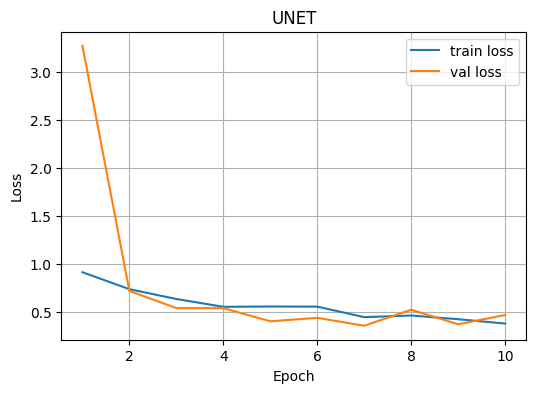

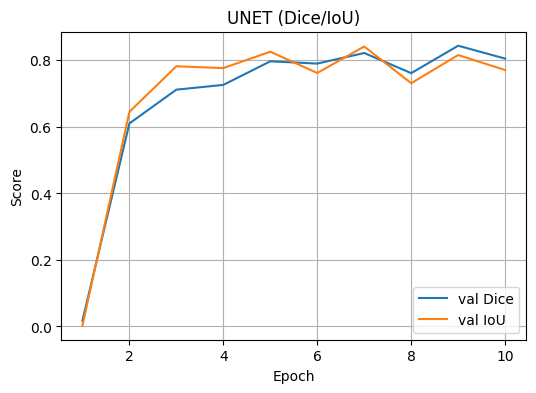

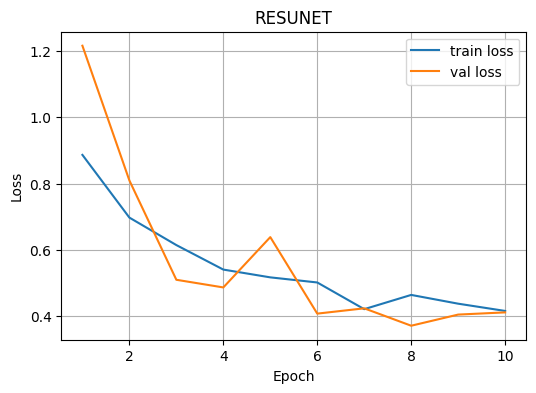

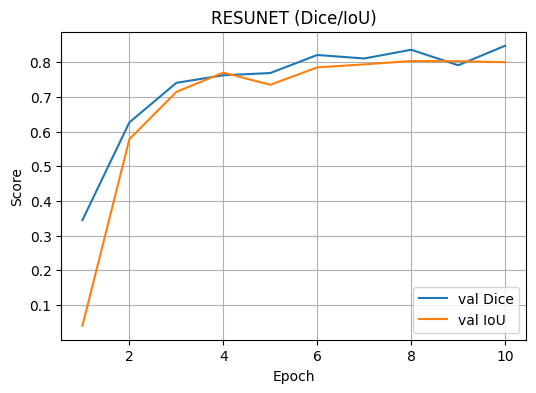

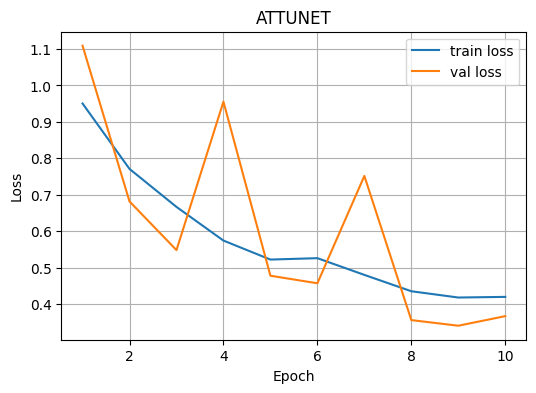

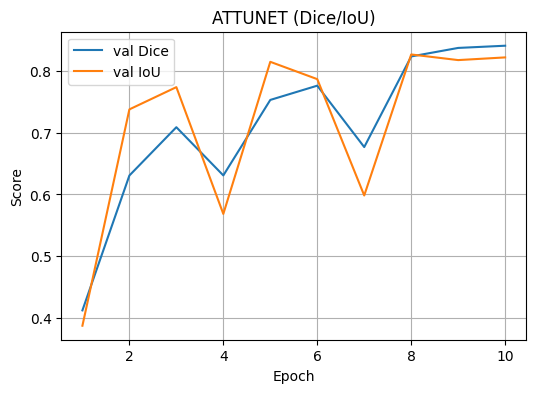

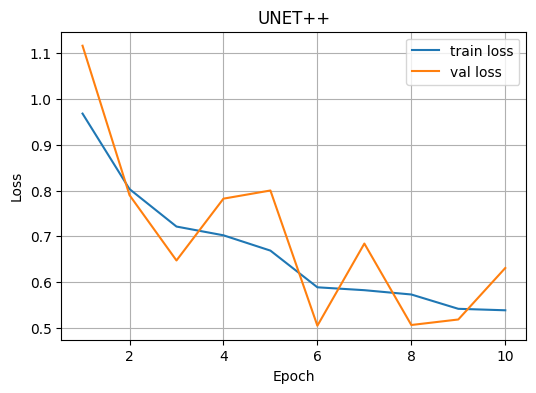

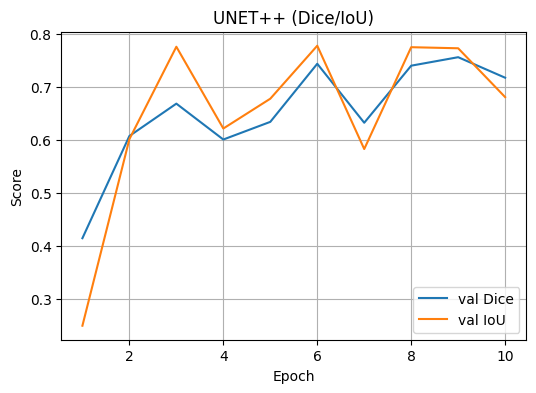

In [ ]:
# ========================= Summarize & Plot (Force Output) ====================
import pandas as pd
from IPython.display import display


def plot_history(history, title="Training Curves"):
    if not history["train_loss"]:
        print("No history to plot.")
        return
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(6,4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(title); plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, history["val_dice"], label="val Dice")
    plt.plot(epochs, history["val_iou"],  label="val IoU")
    plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title(title+" (Dice/IoU)"); plt.legend(); plt.grid(True)
    plt.show()

if 'results' in globals() and len(results) > 0:
    df = pd.DataFrame([{k:v for k,v in r.items() if k!='history' and k!='state_dict'} for r in results])
    display(df)  # Use print instead of display

    for r in results:
        plot_history(r["history"], title=r["model"].upper())
else:
    print("No results yet. Train first, then re-run.")


C:\Users\dell\AppData\Local\Temp\ipykernel_18824\953013799.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{mname}_best.pth"))  # or 

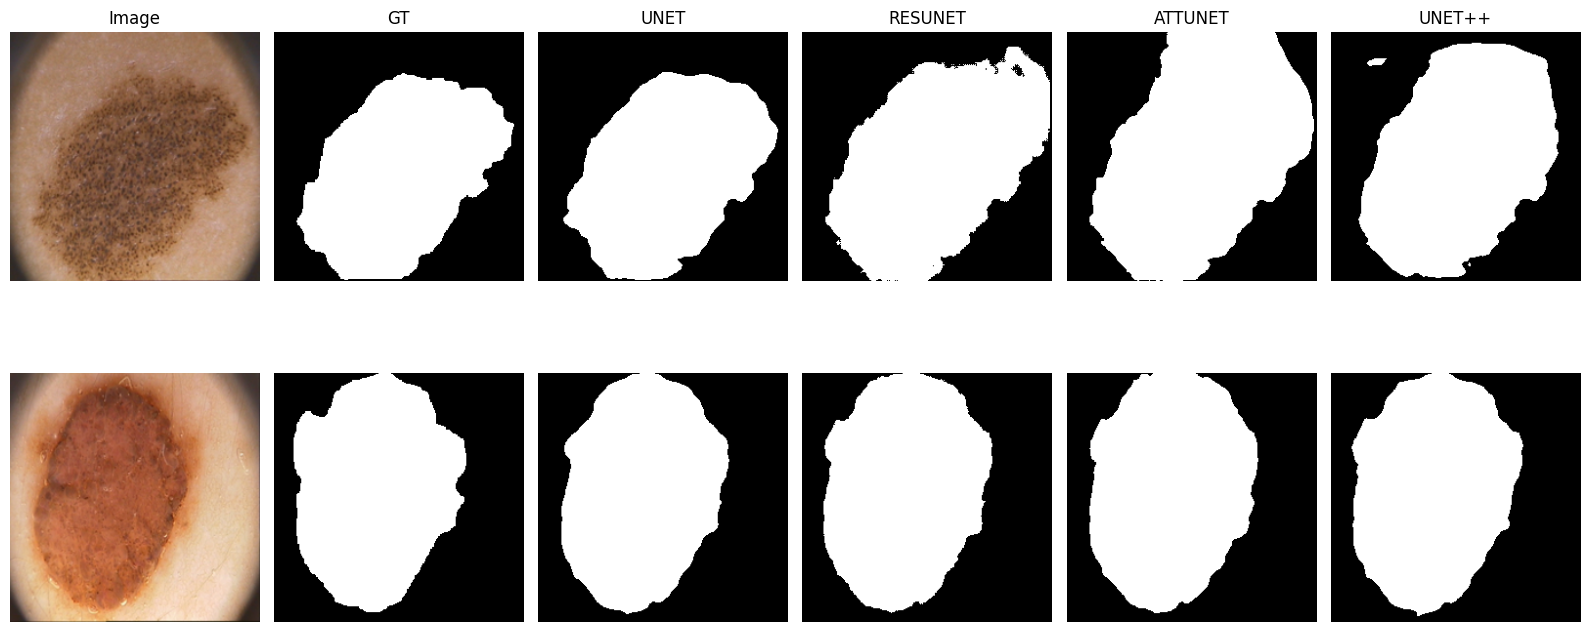

In [ ]:

# =============================== Qualitative Comparisons =======================
@torch.no_grad()
def visualize_predictions(models, loader, n=3, thresh=0.5):
    models = [(name, m.eval()) for name, m in models]
    batch = next(iter(loader), None)
    if batch is None:
        print("Empty loader.")
        return
    imgs, masks = batch
    imgs, masks = imgs.to(device), masks.to(device)
    k = min(n, imgs.size(0))

    plt.figure(figsize=(4 + 3*len(models), 4*k))
    for i in range(k):
        im = (imgs[i].cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)
        gt = (masks[i].cpu().numpy().squeeze()*255).astype(np.uint8)
        plt.subplot(k, 2+len(models), i*(2+len(models)) + 1); plt.imshow(im); plt.axis('off');
        if i==0: plt.title("Image")
        plt.subplot(k, 2+len(models), i*(2+len(models)) + 2); plt.imshow(gt, cmap='gray'); plt.axis('off');
        if i==0: plt.title("GT")

        for j, (name, model) in enumerate(models):
            logit = model(imgs[i][None, ...])
            prob = torch.sigmoid(logit)[0,0].cpu().numpy()
            pred = (prob>thresh).astype(np.uint8)*255
            plt.subplot(k, 2+len(models), i*(2+len(models)) + 3 + j); plt.imshow(pred, cmap='gray'); plt.axis('off')
            if i==0: plt.title(name.upper())
    plt.tight_layout(); plt.show()

# After training, use your trained models:
if 'results' in globals() and len(results) > 0:
    trained_models = []
    for r in results:
        mname = r["model"]
        model = make_model(mname, in_ch=3, out_ch=1, base=32).to(device)
        model.load_state_dict(torch.load(f"{mname}_best.pth"))  # or use r['state_dict'] if you saved it
        trained_models.append((mname, model))
    visualize_predictions(trained_models, val_loader, n=2)
else:
    print("No trained models available. Train first, then visualize.")


## Exercises (for practice)
1. **Ablation:** Replace residual blocks with plain conv blocks in ResU‑Net and compare.
2. **Attention strength:** Change the intermediate channel size in attention gates and observe effects.
3. **Deep supervision:** Enable it in U‑Net++ (set `deep_supervision=True`) and combine losses from multiple heads.
4. **Augmentations:** Add color jitter / elastic transforms. Does Dice improve or degrade?
5. **Losses:** Try **Tversky** or **Focal loss** for class imbalance. Compare ROC/PR curves.
6. **Thresholds:** Sweep prediction threshold (0.3–0.7). Which threshold maximizes IoU on the val set?
7. **Inference speed:** Measure FPS for each model on CPU/GPU and discuss the accuracy–speed trade-off.



---

## What’s Next? Practical 25 on Development Pipeline & Streamlit UI  

In **Practical 25**, we will move toward a **complete development pipeline** for a computer vision project:  

- How to organize dataset preparation, training, evaluation, and model saving.  
- How to track experiments and version models.  
- How to design and deploy a **simple interactive interface** for computer vision project.  
  - We will use tools such as **Gradio** (or similar frameworks) to build a lightweight demo app.    

By the end of the next practical, you’ll have a **mini end-to-end pipeline**, from dataset to deployable interface, showing how research code can evolve into a usable application.  

---


📝 This practical was designed to give you a concise, hands-on comparison of the **U-Net** family (**U-Net, ResU-Net, Attention U-Net, U-Net++**) for skin lesion segmentation on the PH2 dataset.